# Import + GPU Setup + Mixed Precision

In [ ]:
# ============================================================
# PART 1 — IMPORT & GPU SETUP
# ============================================================
!pip install Optuna
!pip install transformers
import tensorflow as tf
from tensorflow.keras import mixed_precision
import numpy as np
import pandas as pd
import gc

from transformers import TFDistilBertModel, DistilBertTokenizerFast
from tensorflow.keras.layers import Input, Bidirectional, GRU, GlobalMaxPooling1D, Dropout, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report

import optuna

# Enable mixed precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Memory growth enabled on GPU")
    except:
        pass


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 14.3 MB/s eta 0:00:00
Memory growth enabled on GPU


# Global Parameters

In [ ]:
MAX_LEN = 64       # Dikurangi dari 128 → hemat memori
BATCH_SIZE = 8     # Dikurangi dari 16 → aman untuk T4
EPOCHS = 1         # Sementara untuk Optuna testing



# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test split 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total → 12.5% dari 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


1445 207 414


# Load Tokenizer + Tokenize Function

In [ ]:
# ============================================================
# PART 4 — TOKENIZER
# ============================================================

tokenizer = DistilBertTokenizerFast.from_pretrained("cahya/distilbert-base-indonesian")

def tokenize(texts):
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        truncation=True,
        padding="max_length",
        return_tensors="tf"
    )


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

# Tokenisasi data Split Train/Test/Val

In [ ]:
train_inputs = tokenize(X_train)
val_inputs   = tokenize(X_val)
test_inputs  = tokenize(X_test)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


# Load Model Distilbert Indonesia Lang

In [ ]:
# ============================================================
# PART 6 — LOAD BERT MODEL ONCE (IMPORTANT)
# ============================================================

bert_model = TFDistilBertModel.from_pretrained("cahya/distilbert-base-indonesian", from_pt=True)
bert_model.trainable = False   # freeze → hemat memory

# Explicitly build the bert_model to define its input shape for Keras functional API
# (None, MAX_LEN) for input_ids and (None, MAX_LEN) for attention_mask
bert_model.build(input_shape=[(None, MAX_LEN), (None, MAX_LEN)])

pytorch_model.bin:   0%|          | 0.00/273M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_projector.weight', 'vocab_transform.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the mode

# Build Model Function

In [ ]:
# ============================================================
# PART 7 — BUILD MODEL FUNCTION
# ============================================================

# Define a wrapper for the frozen bert_model
class BertWrapper(tf.keras.layers.Layer):
    def __init__(self, bert_model_instance, **kwargs):
        super().__init__(**kwargs)
        # Register the bert_model_instance as a sub-layer explicitly
        self.bert_model = bert_model_instance

    def call(self, inputs):
        input_ids, attention_mask = inputs
        # The transformers model expects keyword arguments
        return self.bert_model(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)[0]

def build_model(gru_units, dropout_rate, lr):

    input_ids = Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
    att_mask  = Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

    # Instantiate the wrapper with the global bert_model
    bert_wrapper = BertWrapper(bert_model, name="bert_wrapper_layer")
    hidden_states = bert_wrapper([input_ids, att_mask]) # Pass inputs as a list/tuple

    x = Bidirectional(GRU(gru_units, return_sequences=True))(hidden_states)
    x = GlobalMaxPooling1D()(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid", dtype="float32")(x)

    model = Model(inputs=[input_ids, att_mask], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Optuna Objective Function

In [ ]:
# ============================================================
# PART 8 — OPTUNA OBJECTIVE
# ============================================================

def objective(trial):

    gru_units = trial.suggest_int("gru_units", 32, 64)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.4)
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    # Ensure y_train is a NumPy array for consistent positional indexing
    y_train_np = y_train.values if isinstance(y_train, pd.Series) else y_train

    for tr_idx, va_idx in skf.split(train_inputs["input_ids"], y_train_np):

        fold_train = {
            "input_ids": tf.gather(train_inputs["input_ids"], tr_idx),
            "attention_mask": tf.gather(train_inputs["attention_mask"], tr_idx)
        }
        fold_val = {
            "input_ids": tf.gather(train_inputs["input_ids"], va_idx),
            "attention_mask": tf.gather(train_inputs["attention_mask"], va_idx)
        }

        # Use the NumPy array for indexing
        y_tr = y_train_np[tr_idx]
        y_va = y_train_np[va_idx]

        model = build_model(gru_units, dropout_rate, lr)

        model.fit(
            fold_train,
            y_tr,
            validation_data=(fold_val, y_va),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        preds = (model.predict(fold_val, batch_size=BATCH_SIZE) > 0.5).astype(int)
        f1 = f1_score(y_va, preds)
        f1_scores.append(f1)

        tf.keras.backend.clear_session()
        gc.collect()

    return np.mean(f1_scores)

# Run Optuna Study

In [ ]:
# ============================================================
# PART 9 — RUN OPTUNA
# ============================================================

# y_train is already a NumPy array due to a previous execution, so no further conversion is needed.

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

best = study.best_params
print("Best parameters:", best)

[I 2025-11-30 07:20:06,063] A new study created in memory with name: no-name-1857a7fb-e208-44d9-ae36-f3ccc81e91ab


37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step


[I 2025-11-30 07:22:11,673] Trial 0 finished with value: 0.6454082278799769 and parameters: {'gru_units': 43, 'dropout': 0.3260765198490233, 'lr': 6.093602865374881e-05}. Best is trial 0 with value: 0.6454082278799769.


37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step


[I 2025-11-30 07:24:01,371] Trial 1 finished with value: 0.5584856922639186 and parameters: {'gru_units': 38, 'dropout': 0.3472969175731525, 'lr': 2.329586172004266e-05}. Best is trial 0 with value: 0.6454082278799769.


...

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step


[I 2025-11-30 07:27:27,334] Trial 3 finished with value: 0.7286606666189679 and parameters: {'gru_units': 59, 'dropout': 0.3586472989287547, 'lr': 6.776318142697618e-05}. Best is trial 3 with value: 0.7286606666189679.


37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step


[I 2025-11-30 07:29:36,878] Trial 4 finished with value: 0.8350535919284982 and parameters: {'gru_units': 43, 'dropout': 0.3294464290655994, 'lr': 0.000356063920879353}. Best is trial 4 with value: 0.8350535919284982.


Best parameters: {'gru_units': 43, 'dropout': 0.3294464290655994, 'lr': 0.000356063920879353}


# Training Final Model

In [ ]:
# ============================================================
# PART 10 — TRAIN FINAL MODEL
# ============================================================

final_model = build_model(
    best["gru_units"],
    best["dropout"],
    best["lr"]
)

final_model.fit(
    dict(train_inputs),
    y_train,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=(dict(val_inputs), y_val.values) # Pass validation data explicitly as a dictionary
)

Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.6836 - loss: 0.5744 - val_accuracy: 0.8213 - val_loss: 0.3917
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.8675 - loss: 0.3142 - val_accuracy: 0.8164 - val_loss: 0.3803
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9060 - loss: 0.2482 - val_accuracy: 0.8599 - val_loss: 0.3287
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9178 - loss: 0.2247 - val_accuracy: 0.8454 - val_loss: 0.3431
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9502 - loss: 0.1532 - val_accuracy: 0.8551 - val_loss: 0.3349
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9565 - loss: 0.1403 - val_accuracy: 0.8841 - val_loss: 0.2983
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9794 - loss: 0.0820 - val_accuracy: 0.8889 - val_loss: 0.2828
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9812 - loss: 0.0723 - val_acc

# Evaluation on Test Set

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step
              precision    recall  f1-score   support

         0.0     0.8966    0.9123    0.9043       228
         1.0     0.8901    0.8710    0.8804       186

    accuracy                         0.8937       414
   macro avg     0.8933    0.8916    0.8924       414
weighted avg     0.8937    0.8937    0.8936       414



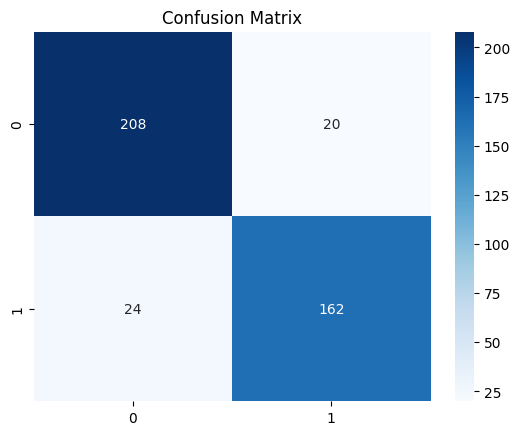

Macro F1: 0.8923913043478261


In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (final_model.predict(dict(test_inputs)) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

# Experiment Configuration :

In [ ]:
import json
from pprint import pprint

# Infer embedding dimension from the loaded bert_model config
embedding_dim = bert_model.config.hidden_size

experiment_config = {
    "experiment_name": "Bi-GRU + DistilBERT Embedding + Max Pooling",
    "framework": "TensorFlow 2.x",
    "precision": "mixed_float16",
    "tokenizer": {
        "type": "DistilBertTokenizerFast",
        "pretrained_model": "cahya/distilbert-base-indonesian",
        "max_length": MAX_LEN,
        "truncation": True,
        "padding": "max_length",
        "return_tensors": "tf"
    },
    "embedding": {
        "type": "DistilBERT",
        "pretrained_model": "cahya/distilbert-base-indonesian",
        "trainable": False,
        "output_type": "hidden_states",
        "embedding_dim": embedding_dim,
        "pooling": "max pooling (GlobalMaxPooling1D after Bi-GRU)"
    },
    "sequence_model": {
        "type": "Bidirectional GRU",
        "gru_units_range": [32, 64],  # Optuna search space
        "return_sequences": True,
        "dropout": {
            "range": [0.1, 0.4],  # Optuna search space
        }
    },
    "dense_head": {
        "activation": "sigmoid",
        "output_dim": 1,
        "dtype": "float32"
    },
    "optimizer": {
        "type": "Adam",
        "learning_rate_range": [1e-5, 5e-4]  # Optuna search space
    },
    "training": {
        "batch_size": BATCH_SIZE,
        "epochs_final": 10,
        "epochs_optuna": EPOCHS,
        "validation_split": "via StratifiedKFold (5-fold CV)",
        "loss": "binary_crossentropy",
        "metrics": ["accuracy"]
    },
    "dataset": {
        "train_size": len(X_train),
        "val_size": len(X_val),
        "test_size": len(X_test),
        "label_encoding": "encoded_label",
        "text_column": "clean_text"
    },
    "hyperparameter_optimization": {
        "library": "Optuna",
        "direction": "maximize",
        "trials": 5,
        "search_spaces": {
            "gru_units": [32, 64],
            "dropout": [0.1, 0.4],
            "learning_rate": [1e-5, 5e-4]
        }
    }
}

print("\nExperiment Configuration:")
pprint(experiment_config)

print("\nJSON Format:")
print(json.dumps(experiment_config, indent=4))



Experiment Configuration:
{'dataset': {'label_encoding': 'encoded_label',
             'test_size': 414,
             'text_column': 'clean_text',
             'train_size': 1445,
             'val_size': 207},
 'dense_head': {'activation': 'sigmoid', 'dtype': 'float32', 'output_dim': 1},
 'embedding': {'embedding_dim': 768,
               'output_type': 'hidden_states',
               'pooling': 'mean pooling (GlobalAveragePooling1D after Bi-GRU)',
               'pretrained_model': 'cahya/distilbert-base-indonesian',
               'trainable': False,
               'type': 'DistilBERT'},
 'experiment_name': 'Bi-GRU + DistilBERT Embedding + Mean Pooling',
 'framework': 'TensorFlow 2.x',
 'hyperparameter_optimization': {'direction': 'maximize',
                                 'library': 'Optuna',
                                 'search_spaces': {'dropout': [0.1, 0.4],
                                                   'gru_units': [32, 64],
                                         